#  library

In [261]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2 as cv 
import os

# image processed

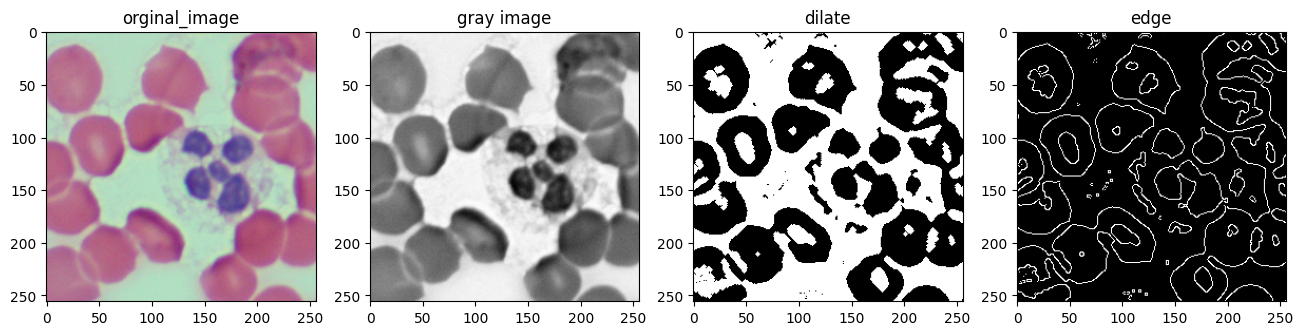

In [262]:
image = cv.imread("images/image-105.png", cv.IMREAD_COLOR)
image_rgb = cv.cvtColor(image, cv.COLOR_BGR2RGB)
gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
binary =cv.adaptiveThreshold(gray, 255,cv.ADAPTIVE_THRESH_GAUSSIAN_C,cv.THRESH_BINARY, 55, 2)
# _, thresh = cv.threshold(gray, 100, 255, cv.THRESH_BINARY_INV + cv.THRESH_OTSU)
kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, (3,3))
# cleaned1 = cv.morphologyEx(binary, cv.MORPH_OPEN, kernel, iterations=1)
cleaned = cv.morphologyEx(binary, cv.MORPH_OPEN, kernel, iterations=2)
edge = cv.Canny(cleaned,0, 255)

plt.figure(figsize=(16, 16))
plt.subplot(1, 4, 1)
plt.title('orginal_image')
plt.imshow(image_rgb)

plt.subplot(1, 4, 2)
plt.title('gray image')
plt.imshow(gray, cmap='gray')

plt.subplot(1, 4, 3)
plt.title('dilate')
plt.imshow(cleaned, cmap='gray')

plt.subplot(1, 4, 4)
plt.title('edge')
plt.imshow(edge, cmap='gray')

plt.show()



# Feature Extraction

In [263]:
#find contours
contours, _ = cv.findContours(edge, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE) 

feature = []
for cnt in contours:
    area = cv.contourArea(cnt)
    if area <50:
        continue
    perimeter = cv.arcLength(cnt, True)
    circularity = 4 * np.pi * area / (perimeter**2 + 1e-6)
    feature.append([area, perimeter, circularity])

features_data = pd.DataFrame(feature, columns=["Area", "Perimeter", "Circularity"])
features_data.shape


(19, 3)

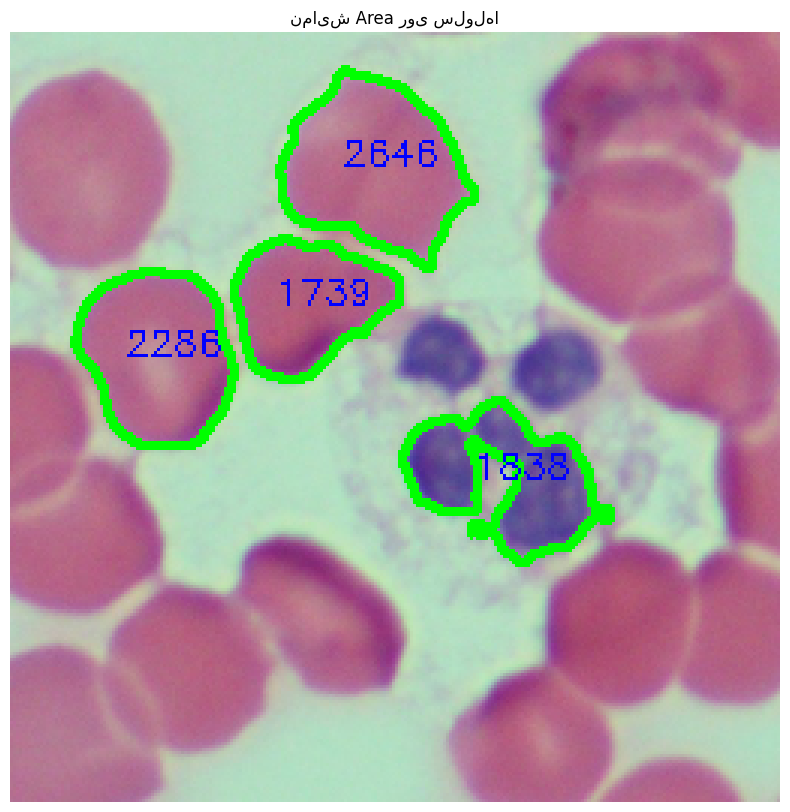

In [264]:

for cnt in contours:
    area = cv.contourArea(cnt)
    if area < 1000:  # همون فیلتری که در استخراج ویژگی زدی
        continue
    perimeter = cv.arcLength(cnt, True)
    circularity = 4 * np.pi * area / (perimeter**2 + 1e-6)
    

    # کشیدن کانتور
    cv.drawContours(image, [cnt], -1, (0, 255, 0), 2)

    # پیدا کردن مرکز کانتور
    M = cv.moments(cnt)
    if M["m00"] != 0:
        cx = int(M["m10"]/M["m00"])
        cy = int(M["m01"]/M["m00"])
        # نوشتن Area یا Circularity روی تصویر
        cv.putText(image, f"{int(area)}", (cx-10, cy), cv.FONT_HERSHEY_SIMPLEX, 0.4, (255, 0, 0), 1)

# نمایش تصویر
plt.figure(figsize=(10,10))
plt.imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB))
plt.title("نمایش Area روی سلول‌ها")
plt.axis('off')
plt.show()